In [1]:
import pandas as pd
import torch 
import matplotlib as pyplt
import tqdm 

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv')
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
#parsing the pipe string into list for training 
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np 
df['labels'] = df['Finding Labels'].apply(lambda x: x.split('|')) 

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(df['labels'])

# Remove No Finding from classes before creating dataframe
disease_cols = [c for c in mlb.classes_ if c != 'No Finding']
no_finding_idx = list(mlb.classes_).index('No Finding')

# Drop No Finding column from labels array
labels = np.delete(labels, no_finding_idx, axis=1)

# Drop if already exist
df = df.drop(columns=[c for c in disease_cols if c in df.columns], errors='ignore')
df = df.drop(columns=['No Finding'], errors='ignore')
df = df.reset_index(drop=True)

label_df = pd.DataFrame(labels, columns=disease_cols)
df = pd.concat([df, label_df], axis=1)

print(len(disease_cols))  # should be 14
print(df[disease_cols].head())

14
   Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  \
0            0             1              0      0         0          0   
1            0             1              0      0         0          1   
2            0             1              0      0         1          0   
3            0             0              0      0         0          0   
4            0             0              0      0         0          0   

   Fibrosis  Hernia  Infiltration  Mass  Nodule  Pleural_Thickening  \
0         0       0             0     0       0                   0   
1         0       0             0     0       0                   0   
2         0       0             0     0       0                   0   
3         0       0             0     0       0                   0   
4         0       1             0     0       0                   0   

   Pneumonia  Pneumothorax  
0          0             0  
1          0             0  
2          0             0  
3  

In [4]:
from sklearn.model_selection import train_test_split
with open('/kaggle/input/datasets/organizations/nih-chest-xrays/data/train_val_list.txt') as f:
    train_val_files = set(f.read().splitlines())
with open('/kaggle/input/datasets/organizations/nih-chest-xrays/data/test_list.txt') as f:
    test_files = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_files)].reset_index(drop=True)
test_df = df[df['Image Index'] .isin(test_files)].reset_index(drop=True)

#spliting pateints by ID and not randomly to prevent data leak 
patients = train_val_df['Patient ID'].unique()
train_patients, val_patients = train_test_split(patients, test_size=0.2, random_state=42) 

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f" Train lenght:{len(train_df)} | test lenght:{len(test_df)} | val lenght:{len(val_df)}")

 Train lenght:69625 | test lenght:25596 | val lenght:16899


In [5]:
import os

base_dir = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'

image_paths = {}
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path) and 'image' in folder.lower():
        images_subdir = os.path.join(folder_path, 'images')
        if os.path.isdir(images_subdir):
            for fname in os.listdir(images_subdir):
                image_paths[fname] = os.path.join(images_subdir, fname)

print(f'Total images found: {len(image_paths)}')

Total images found: 112120


In [6]:
#Creating a custom dataset class 
import os
import torch
from PIL import Image 
import numpy as np
from torch.utils.data import Dataset, DataLoader

class ChestXRay(Dataset):
    def __init__(self, df, image_paths, transform=None):
        self.df          = df.reset_index(drop=True)      
        self.image_paths = image_paths
        self.transform   = transform
        self.labels      = df[disease_cols].values.astype(np.float32)  # separate variable

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name  = self.df.loc[idx, 'Image Index']       
        img_path  = self.image_paths[img_name]            # was img_paths, also wrong variable below
        image     = Image.open(img_path).convert('RGB')   # was image_path not img_path
        if self.transform:
            image = self.transform(image)                 # must reassign, also pass image not img_path
        label = torch.tensor(self.labels[idx])            # square brackets not valid here
        return image, label                               # was images not image

In [7]:
# train_transfrom and test_transform 
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
     transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [8]:
#creating dataset 
train_dataset = ChestXRay(train_df, image_paths, transform=train_transform)
test_dataset  = ChestXRay(test_df,  image_paths, transform=val_test_transform)
val_dataset   = ChestXRay(val_df,   image_paths, transform=val_test_transform)

print(len(train_dataset), len(test_dataset), len(val_dataset))

69625 25596 16899


In [9]:
#Turning dataset into Dataloader
from torch.utils.data import DataLoader

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, drop_last=True)
valloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, drop_last=True)

print(len(trainloader), len(testloader), len(valloader))

2175 799 528


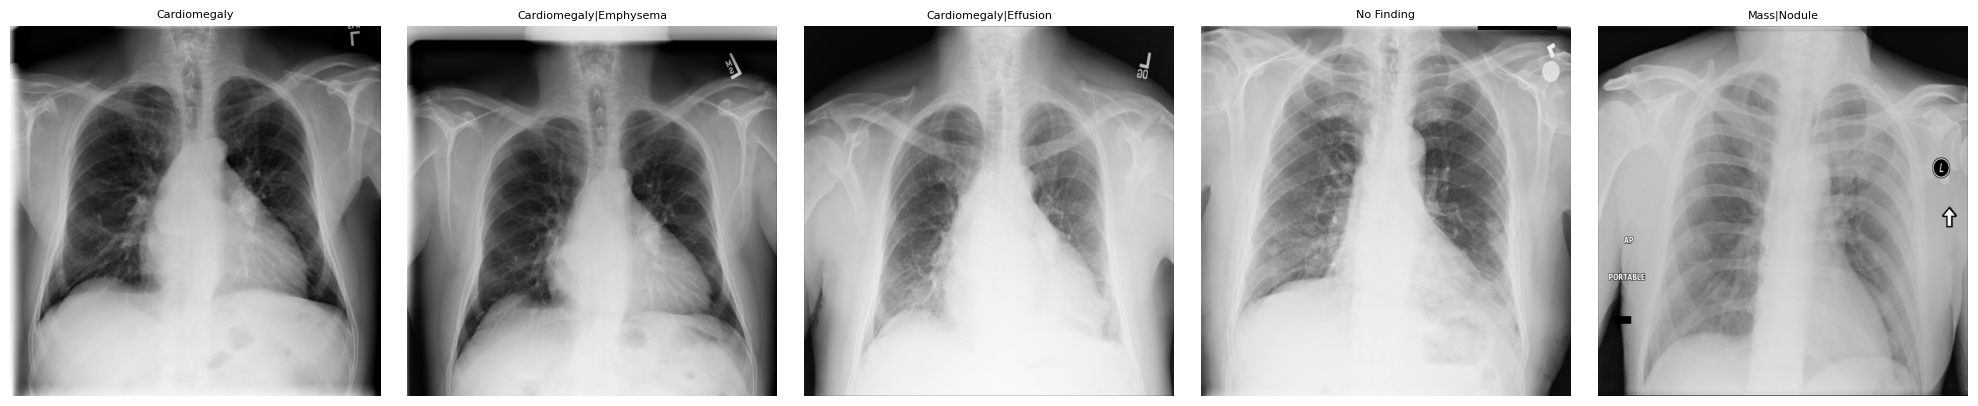

In [10]:
disease_cols = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
                'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
                'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    img_name = train_df.loc[i, 'Image Index']
    img_path = image_paths[img_name]
    label    = train_df.loc[i, 'Finding Labels']
    
    image = Image.open(img_path).convert('RGB')
    
    ax.imshow(image, cmap='gray')
    ax.set_title(label, fontsize=8, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [12]:
#Initialing the model
import torch.nn
import torchvision
model = torchvision.models.densenet121(weights='DEFAULT', progress=True).to(device)
model.classifier = torch.nn.Linear(1024, 14)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 272MB/s]


In [13]:
# Creating pos_weight
disease_cols = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
                'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
                'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
pos_positive = train_df[disease_cols].sum()
pos_neg = len(train_df) - pos_positive 
pos_weight = ( pos_neg / pos_positive ).values
pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

In [14]:
#optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [38]:
# AUC-ROC score
from sklearn.metrics import roc_auc_score
import numpy as np


def roc_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_preds  = []

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device)
            output = model(images)
            preds  = torch.sigmoid(output).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    #AUC per disease
    aucs = []
    for i, disease in enumerate(disease_cols):
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        aucs.append(auc)
        print(f"{disease}: {auc:.4f}")

    print(f'\nMean AUC: {np.mean(aucs):.4f}')
    return np.mean(aucs)